In [1]:


import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('../Data/processed/project.duckdb')

In [7]:
#: How much data do we actually have?

con.execute("""
    SELECT COUNT(*) AS total_trades,
           COUNT(DISTINCT accountId) AS total_accounts,
           COUNT(DISTINCT campaignId) AS total_campaigns
    FROM trades
""").fetchdf()

,total_trades,total_accounts,total_campaigns
0,46520,502,34


a note here - in the provided datasets, we dont have campaigns 1-66 but 33-66 lolol 

In [8]:
#Rows per campaign

con.execute("""
    SELECT campaignId, COUNT(*) AS num_trades
    FROM trades
    GROUP BY campaignId
    ORDER BY campaignId
""").fetchdf()

,campaignId,num_trades
0,33,749
1,34,942
2,35,1030
3,36,1457
4,37,1432
5,38,1271
6,39,1180
7,40,1432
8,41,1227
9,42,1674


In [9]:
# Trades per account 

con.execute("""
    SELECT accountId, COUNT(*) AS num_trades
    FROM trades
    GROUP BY accountId
    ORDER BY num_trades DESC
""").fetchdf()

,accountId,num_trades
0,D#1702482,228
1,D#1702476,208
2,D#1702452,202
3,D#1702696,193
4,D#1702588,193
...,...,...
497,D#1702712,31
498,D#1702384,30
499,D#1645625,7
500,D#1645639,2


In [10]:
# avg trades per account
con.execute("""
    WITH trade_counts AS (
        SELECT accountId, COUNT(*) AS num_trades
        FROM trades
        GROUP BY accountId
    )
    SELECT 
        AVG(num_trades) AS avg_trades_per_account,
        MEDIAN(num_trades) AS median_trades_per_account,
        MODE(num_trades) AS mode_trades_per_account
    FROM trade_counts
""").fetchdf()

,avg_trades_per_account,median_trades_per_account,mode_trades_per_account
0,92.669323,90.0,71


In [11]:
#distribution check

con.execute("""
    SELECT 
        MIN(netProfit) AS min_profit, MAX(netProfit) AS max_profit, AVG(netProfit) AS avg_profit,
        MIN(durationSec) AS min_duration, MAX(durationSec) AS max_duration, AVG(durationSec) AS avg_duration,
        MIN(amount) AS min_lot, MAX(amount) AS max_lot, AVG(amount) AS avg_lot
    FROM trades
""").fetchdf()

,min_profit,max_profit,avg_profit,min_duration,max_duration,avg_duration,min_lot,max_lot,avg_lot
0,-944.1,680.64,-6.686877,0,79210,1415.867261,0.01,0.63,0.18378


In [12]:
#missing values 

con.execute("""
    SELECT 
        SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) AS no_sl_count,
        SUM(CASE WHEN tpPrice IS NULL THEN 1 ELSE 0 END) AS no_tp_count,
        COUNT(*) AS total
    FROM trades
""").fetchdf()

,no_sl_count,no_tp_count,total
0,24601.0,20930.0,46520


This is actually a really meaningful result — let's break it down.
What it's saying
Out of 46,520 total trades:

24,601 trades (≈53%) had no stop-loss set
20,930 trades (≈45%) had no take-profit set

Why this matters
Remember — this isn't "missing data" to clean away, it's a behavior signal in disguise. Over half your trades were placed with no stop-loss at all. That's a genuinely notable finding on its own, even before you build anything fancier:

No-SL trading is a classic risk-blindness/overconfidence pattern
You could directly test: do accounts with a higher no-SL rate breach the drawdown/consistency rules more often, or perform worse overall?
This alone could be one of your first real hypotheses for the memo: "Traders who don't set stop-losses are more likely to hard-breach or underperform vs. traders who consistently use them."

In [13]:
#Is the no-SL behavior spread evenly across traders, or concentrated in a subset?

con.execute("""
    SELECT accountId,
           COUNT(*) AS total_trades,
           SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) AS no_sl_trades,
           ROUND(SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS no_sl_pct
    FROM trades
    GROUP BY accountId
    HAVING COUNT(*) >= 10
    ORDER BY no_sl_pct DESC
""").fetchdf()

,accountId,total_trades,no_sl_trades,no_sl_pct
0,D#1702501,94,87.0,92.6
1,D#1670967,100,92.0,92.0
2,D#1702476,208,190.0,91.3
3,D#1702471,110,95.0,86.4
4,D#1702503,79,68.0,86.1
...,...,...,...,...
494,D#1702667,65,15.0,23.1
495,D#1670918,101,23.0,22.8
496,D#1702457,155,35.0,22.6
497,D#1671059,88,17.0,19.3


we should explore this more.... 
we can export this output to a csv file, put it on tablue and check it out 


In [2]:
# What tables exist in the database?
con.execute("SHOW TABLES").fetchdf()

,name
0,trades
1,users


In [3]:
# Schema of the trades table — column names + types
con.execute("DESCRIBE trades").fetchdf()

,column_name,column_type,null,key,default,extra
0,accountId,VARCHAR,YES,None,None,None
1,instrument,VARCHAR,YES,None,None,None
2,lotSize,BIGINT,YES,None,None,None
3,closeTradeId,DOUBLE,YES,None,None,None
4,positionId,DOUBLE,YES,None,None,None
5,closeOrderId,DOUBLE,YES,None,None,None
6,openOrderId,DOUBLE,YES,None,None,None
7,durationSec,BIGINT,YES,None,None,None
8,openDateTime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
9,closeDateTime,TIMESTAMP WITH TIME ZONE,YES,None,None,None


In [4]:
# Row count and basic shape
con.execute("SELECT COUNT(*) AS n_rows, COUNT(DISTINCT accountId) AS n_accounts, COUNT(DISTINCT campaignId) AS n_campaigns FROM trades").fetchdf()

,n_rows,n_accounts,n_campaigns
0,46520,502,34


Write down: total rows, total accounts, campaign range, and every column name with its type. You'll refer back to this constantly.



Phase 1 — Data Quality & Integrity (always first, no exceptions)

This is the phase people skip and regret. Bad grain or silent nulls will quietly wreck every conclusion downstream.

In [6]:
con.execute("""
    SELECT COUNT(*) AS distinct_rows
    FROM (SELECT DISTINCT * FROM trades)
""").fetchdf()

,distinct_rows
0,46520


no duplicates

In [8]:
# 1.2 — Missing values, every column, not just SL/TP

cols = con.execute("DESCRIBE trades").fetchdf()['column_name'].tolist()
null_checks = ", ".join([f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}_nulls" for c in cols])
con.execute(f"SELECT {null_checks} FROM trades").fetchdf().T

,0
accountId_nulls,0.0
instrument_nulls,0.0
lotSize_nulls,0.0
closeTradeId_nulls,0.0
positionId_nulls,0.0
closeOrderId_nulls,0.0
openOrderId_nulls,0.0
durationSec_nulls,0.0
openDateTime_nulls,0.0
closeDateTime_nulls,0.0


missing values only exist in sl & tp --> data is overall complete and missing values in sl & tp do indicate behavior (overconfidence & overrisking & poor experience)

In [9]:
# 1.3 range sanity checks
con.execute("""
    SELECT
        MIN(durationSec) AS min_dur, MAX(durationSec) AS max_dur,
        MIN(amount) AS min_lot, MAX(amount) AS max_lot,
        MIN(netProfit) AS min_profit, MAX(netProfit) AS max_profit
    FROM trades
""").fetchdf()

,min_dur,max_dur,min_lot,max_lot,min_profit,max_profit
0,0,79210,0.01,0.63,-944.1,680.64


Range check: All your trades are on a single instrument size range that looks clean (no negative/zero lots), but durations span from instant closes (0 sec) up to a ~22-hour outlier, and losses run noticeably deeper (-944.1) than gains run high (+680.64).


In [11]:
con.execute("""
       SELECT * FROM trades WHERE durationSec = 0
       LIMIT 20
   """).fetchdf()

,accountId,instrument,lotSize,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,...,closePrice,slPrice,tpPrice,side,currency,openTradeCrossPrice,closeTradeCrossPrice,userGroupId,filename,campaignId
0,D#1671050,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-03-03 11:28:51+05:45,2026-03-03 11:28:51+05:45,...,5343.96,5344.08,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 34 Data 03 Mar 2...,34
1,D#1671065,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-03-10 11:17:20+05:45,2026-03-10 11:17:20+05:45,...,5168.68,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 36 Data 09 Mar 2...,36
2,D#1702367,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-03-10 14:20:18+05:45,2026-03-10 14:20:18+05:45,...,5183.29,5190.70,5183.44,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 36 Data 09 Mar 2...,36
3,D#1702573,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-03-11 01:00:00+05:45,2026-03-11 01:00:00+05:45,...,5198.19,5198.80,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 36 Data 09 Mar 2...,36
4,D#1670924,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-03-20 14:59:20+05:45,2026-03-20 14:59:20+05:45,...,4695.24,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 39 Data 20 Mar 2...,39
5,D#1671090,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-04-14 12:50:21+05:45,2026-04-14 12:50:21+05:45,...,4787.13,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 45 Data 14 Apr 2...,45
6,D#1702554,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,0,2026-05-07 12:37:05+05:45,2026-05-07 12:37:05+05:45,...,4739.20,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 50 Data 07 May 2...,50
7,D#1702349,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,0,2026-06-12 16:23:25+05:45,2026-06-12 16:23:25+05:45,...,4216.33,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 60 Data 12 June ...,60
8,D#1702572,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,0,2026-06-16 16:30:35+05:45,2026-06-16 16:30:35+05:45,...,4347.93,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 61 Data 16 June ...,61
9,D#1670971,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,0,2026-06-19 06:57:12+05:45,2026-06-19 06:57:12+05:45,...,4186.63,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 62 Data 19 June ...,62


The 13 zero-duration trades: These are trades where openDateTime and closeDateTime are identical to the second — nearly all have no SL or TP set, suggesting instant fills/closes rather than genuine "held" positions, which is worth excluding or flagging separately when you calculate average hold time.


In [13]:
con.execute("""
       SELECT * FROM trades ORDER BY netProfit ASC LIMIT 20
   """).fetchdf()

con.execute("""
       SELECT * FROM trades ORDER BY netProfit DESC LIMIT 20
   """).fetchdf()

,accountId,instrument,lotSize,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,...,closePrice,slPrice,tpPrice,side,currency,openTradeCrossPrice,closeTradeCrossPrice,userGroupId,filename,campaignId
0,D#1702718,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,99,2026-03-06 17:39:32+05:45,2026-03-06 17:41:11+05:45,...,5065.58,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 35 Data 06 Mar 2...,35
1,D#1702439,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,14,2026-06-05 18:14:56+05:45,2026-06-05 18:15:10+05:45,...,4452.13,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 58 Data 05 June ...,58
2,D#1702506,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,199,2026-06-19 18:45:02+05:45,2026-06-19 18:48:21+05:45,...,4165.94,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 62 Data 19 June ...,62
3,D#1702375,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5985,2026-05-12 19:28:16+05:45,2026-05-12 21:08:01+05:45,...,4644.45,4705.93,4646.06,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 51 Data 12 May 2...,51
4,D#1702524,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,41932,2026-05-29 08:58:32+05:45,2026-05-29 20:37:24+05:45,...,4556.58,4492.31,4556.14,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 56 Data 29 May 2...,56
5,D#1702598,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,2074,2026-06-19 09:09:38+05:45,2026-06-19 09:44:12+05:45,...,4148.84,NaN,4080.23,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 62 Data 19 June ...,62
6,D#1702663,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,6224,2026-03-17 14:08:09+05:45,2026-03-17 15:51:53+05:45,...,5004.27,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 38 Data 17 Mar 2...,38
7,D#1702722,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,115,2026-03-31 19:41:55+05:45,2026-03-31 19:43:50+05:45,...,4607.02,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 42 Data 31 Mar 2...,42
8,D#1702697,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,622,2026-05-19 10:59:00+05:45,2026-05-19 11:09:22+05:45,...,4533.48,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 53 Data 19 May 2...,53
9,D#1702623,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,632,2026-05-08 01:37:18+05:45,2026-05-08 01:47:50+05:45,...,4717.88,4698.84,4724.90,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 50 Data 07 May 2...,50


Top/bottom 20 by netProfit: This is your best/worst trades side by side — duration varies wildly even among the extremes (14 sec up to ~42,000 sec), and SL/TP presence is mixed rather than cleanly split, so the "no-SL causes big losses" story isn't obviously confirmed by eyeballing this table alone — you'd want to actually compare the two groups' stats directly rather than read it visually.


In [14]:
#1.4 — Survivorship check across campaigns. This matters a lot for trading data — if bad accounts quietly vanish from later campaigns, your averages will look artificially healthy.

con.execute("""
    SELECT campaignId, COUNT(DISTINCT accountId) AS active_accounts
    FROM trades
    GROUP BY campaignId
    ORDER BY campaignId
""").fetchdf()

,campaignId,active_accounts
0,33,137
1,34,192
2,35,185
3,36,221
4,37,236
5,38,205
6,39,205
7,40,248
8,41,177
9,42,269


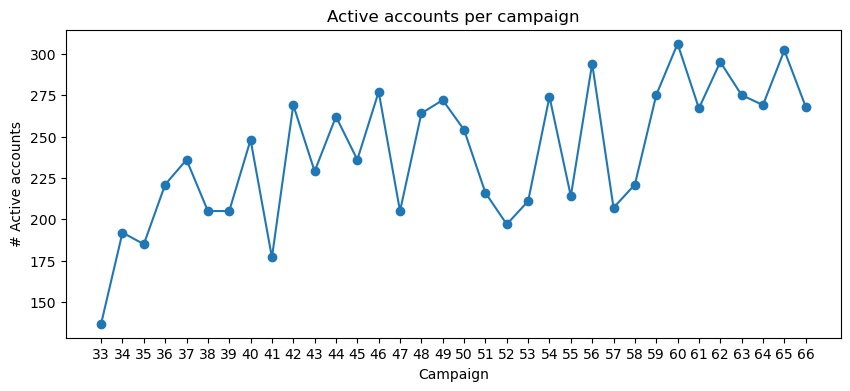

In [15]:
df_survival = con.execute("""
    SELECT campaignId, COUNT(DISTINCT accountId) AS active_accounts
    FROM trades GROUP BY campaignId ORDER BY campaignId
""").fetchdf()
plt.figure(figsize=(10,4))
plt.plot(df_survival['campaignId'], df_survival['active_accounts'], marker='o')
plt.title('Active accounts per campaign')
plt.xlabel('Campaign'); plt.ylabel('# Active accounts')
plt.show()

towards the last few campaigns, there have been more avg number of active accounts - indicates something?

Phase 2 — Univariate Exploration

Look at each variable alone before combining anything.

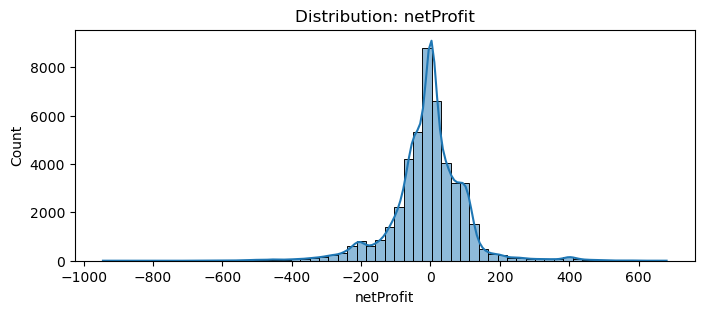

count    46520.000000
mean        -6.686877
std        106.084489
min       -944.100000
25%        -51.700000
50%         -0.660000
75%         45.400000
max        680.640000
Name: netProfit, dtype: float64
Skew: -0.16



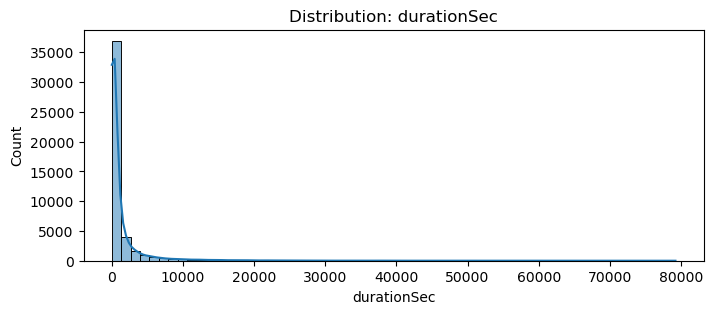

count    46520.000000
mean      1415.867261
std       3935.671774
min          0.000000
25%         78.000000
50%        272.000000
75%        995.000000
max      79210.000000
Name: durationSec, dtype: float64
Skew: 7.08



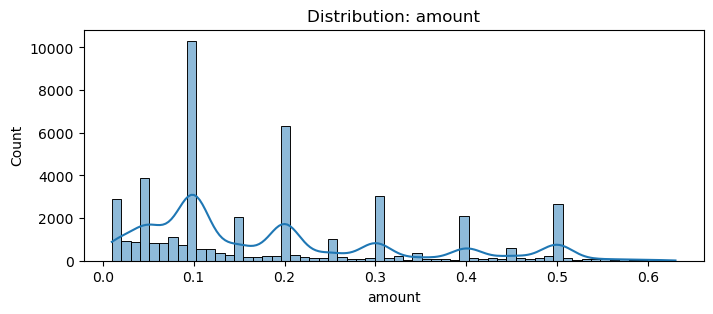

count    46520.000000
mean         0.183780
std          0.144513
min          0.010000
25%          0.090000
50%          0.120000
75%          0.250000
max          0.630000
Name: amount, dtype: float64
Skew: 1.02



In [16]:
#2.1 numeric distribution
df = con.execute("SELECT * FROM trades").fetchdf()

for col in ['netProfit', 'durationSec', 'amount']:
    plt.figure(figsize=(8,3))
    sns.histplot(df[col], bins=60, kde=True)
    plt.title(f'Distribution: {col}')
    plt.show()
    print(df[col].describe())
    print(f"Skew: {df[col].skew():.2f}\n")

**netProfit distribution:** Skew is only -0.16, meaning it's much closer to symmetric than the raw min/max (-944 to +680) suggested — the huge single loss is a genuine outlier, not representative of the overall shape. The median (-0.66) sitting almost exactly at zero tells you the "typical" trade is roughly a wash, and the real story is in the tails, not the center — worth noting that small second bump around +400, which could be a distinct subgroup of trades behaving differently (maybe a specific strategy or account) and is worth isolating.

**durationSec distribution:** Skew of 7.08 is extreme — this confirms your instinct that a small number of very long trades are dragging the mean (1415 sec) way above the median (272 sec). Practically, this means you should always report and reason about duration using the median/percentiles, never the mean, and treat trades beyond roughly the 75th percentile (995 sec) as a separate "long-hold" cohort worth investigating on their own.

**amount (lot size) distribution:** This isn't smooth at all — it's spiky at round numbers (0.1, 0.2, 0.3, 0.4, 0.5), which means lot sizing isn't continuous/organic, it's rule-based or manually chosen in round increments. That's actually a useful behavioral signal: deviations *away* from these round numbers could flag more impulsive or reactive position sizing, which ties directly into feature #10 (compounding entropy) from the behavioral feature list — you could literally define "round-number adherence" as a per-account feature now.

**Taken together:** you now have solid quantitative backing (not just eyeballing) for two of your core hypotheses — durations are genuinely dominated by a short-hold majority with a fat long-tail, and lot sizing follows discrete habits rather than continuous variation. Both are strong, evidence-based points for your memo.

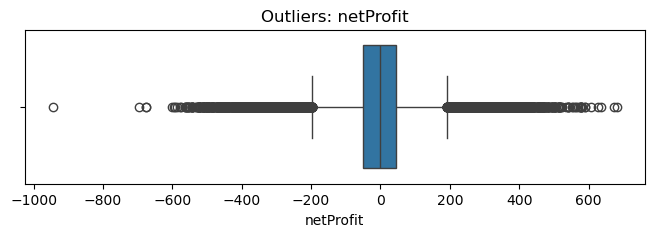

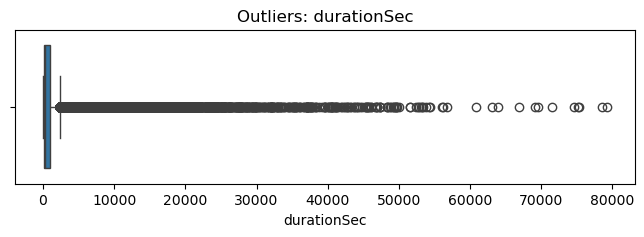

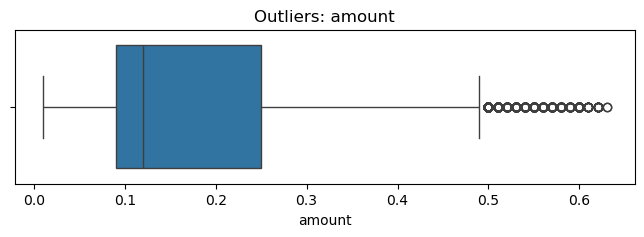

In [17]:
#2.2 boxplots to spot outliers visually
for col in ['netProfit', 'durationSec', 'amount']:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers: {col}')
    plt.show()

In [18]:
# categorical / id cardinality
con.execute("""
    SELECT campaignId, COUNT(*) AS n_trades
    FROM trades GROUP BY campaignId ORDER BY campaignId
""").fetchdf()

,campaignId,n_trades
0,33,749
1,34,942
2,35,1030
3,36,1457
4,37,1432
5,38,1271
6,39,1180
7,40,1432
8,41,1227
9,42,1674


no suspicion above but towards the end, there are more trades

In [ ]:
#2.4 investigating long-duration outlier hypothesis
con.execute("""
    SELECT * FROM trades
    ORDER BY durationSec DESC
    LIMIT 20
""").fetchdf()

,accountId,instrument,lotSize,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,...,closePrice,slPrice,tpPrice,side,currency,openTradeCrossPrice,closeTradeCrossPrice,userGroupId,filename,campaignId
0,D#1702623,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,79210,2026-02-24 09:05:47+05:45,2026-02-25 07:05:57+05:45,...,5183.86,NaN,5491.36,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33
1,D#1670955,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,78536,2026-05-26 08:51:35+05:45,2026-05-27 06:40:31+05:45,...,4517.54,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 55 Data 26 May 2...,55
2,D#1702502,XAUUSD,100,2.882304e+17,2.882304e+17,2.882304e+17,2.882304e+17,75375,2026-06-30 09:46:46+05:45,2026-07-01 06:43:01+05:45,...,3999.00,NaN,3943.24,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 65 Data 30 June ...,65
3,D#1702460,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,75111,2026-05-07 06:55:27+05:45,2026-05-08 03:47:18+05:45,...,4690.09,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 50 Data 07 May 2...,50
4,D#1702379,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,74652,2026-02-24 10:02:15+05:45,2026-02-25 06:46:27+05:45,...,5150.51,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33
5,D#1670951,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,71522,2026-03-17 10:40:34+05:45,2026-03-18 06:32:36+05:45,...,5003.36,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 38 Data 17 Mar 2...,38
6,D#1702441,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,69615,2026-03-24 06:49:46+05:45,2026-03-25 02:10:01+05:45,...,4464.51,4514.00,4158.00,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 40 Data 24 Mar 2...,40
7,D#1589419,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,69086,2026-02-24 11:17:22+05:45,2026-02-25 06:28:48+05:45,...,5150.75,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33
8,D#1702577,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,66947,2026-02-24 12:27:15+05:45,2026-02-25 07:03:02+05:45,...,5179.88,NaN,NaN,SELL,USD,1,1,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33
9,D#1589450,XAUUSD,100,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,63885,2026-04-14 12:50:52+05:45,2026-04-15 06:35:37+05:45,...,4829.82,NaN,NaN,BUY,USD,1,1,1583663,data/raw/user_trades/Campaign 45 Data 14 Apr 2...,45


Phase 3 — Bivariate & Multivariate Exploration


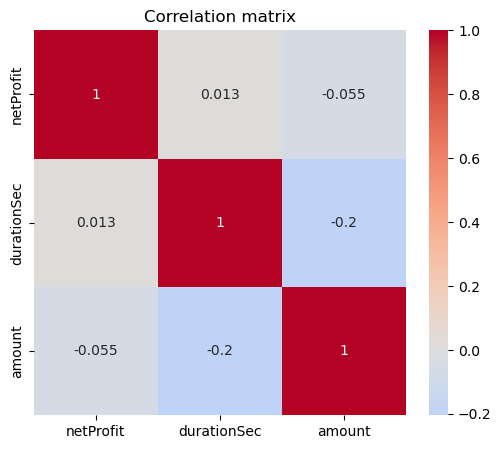

In [20]:
# correlation matrix
numeric_cols = ['netProfit', 'durationSec', 'amount']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

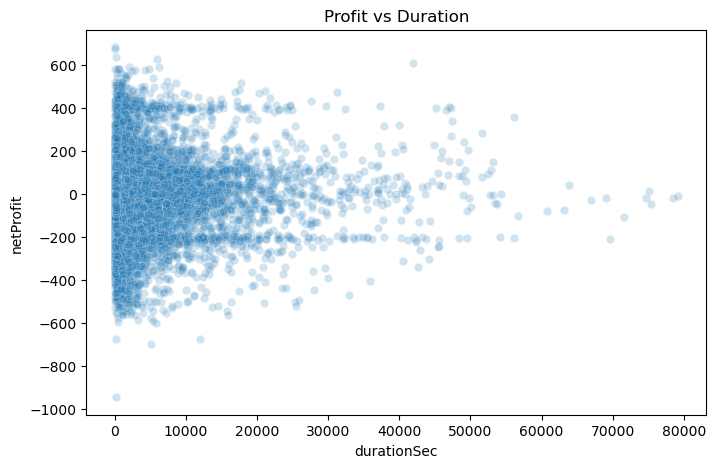

In [21]:
#3.2 profit vs duration
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='durationSec', y='netProfit', alpha=0.2)
plt.title('Profit vs Duration')
plt.show()

In [23]:
# 3.3 profit by sl/tp presence 
con.execute("""
    SELECT
        CASE WHEN slPrice IS NULL THEN 'No SL' ELSE 'Has SL' END AS sl_status,
        COUNT(*) AS n_trades,
        AVG(netProfit) AS avg_profit,
        MEDIAN(netProfit) AS median_profit,
        MIN(netProfit) AS worst_loss
    FROM trades
    GROUP BY sl_status
""").fetchdf()

,sl_status,n_trades,avg_profit,median_profit,worst_loss
0,Has SL,21919,-2.958618,-10.56,-577.8
1,No SL,24601,-10.008681,1.98,-944.1


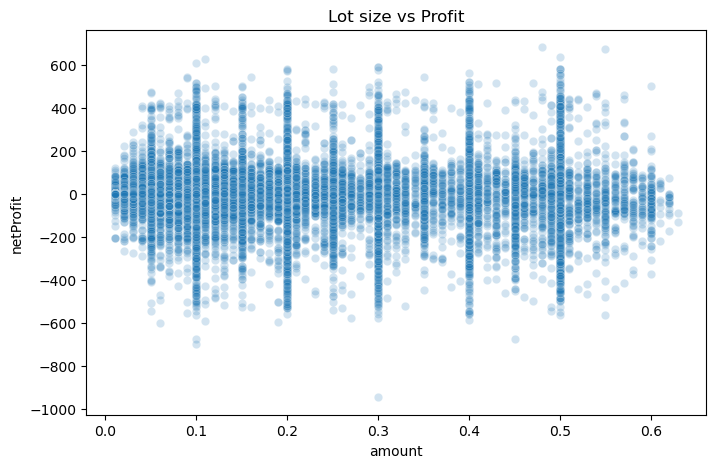

In [24]:
#3.4 lot size vs profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='amount', y='netProfit', alpha=0.2)
plt.title('Lot size vs Profit')
plt.show()

Phase 4 — Time / Campaign-Level Trends



In [25]:
#4.1 trend of key metrics over time across campaigns
con.execute("""
    SELECT
        campaignId,
        COUNT(*) AS n_trades,
        AVG(netProfit) AS avg_profit,
        ROUND(SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS no_sl_pct
    FROM trades
    GROUP BY campaignId
    ORDER BY campaignId
""").fetchdf()

,campaignId,n_trades,avg_profit,no_sl_pct
0,33,749,-8.044860,52.2
1,34,942,-9.084841,62.1
2,35,1030,3.725340,63.5
3,36,1457,2.456246,54.0
4,37,1432,-7.352661,62.8
5,38,1271,-6.414453,59.5
6,39,1180,-1.972644,54.5
7,40,1432,-8.442703,57.0
8,41,1227,-4.687791,45.6
9,42,1674,-2.400800,52.7


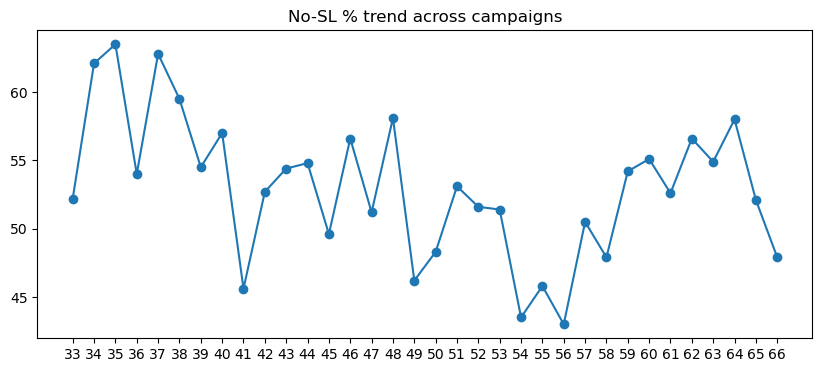

In [26]:
trend = con.execute("""
    SELECT campaignId, ROUND(SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS no_sl_pct
    FROM trades GROUP BY campaignId ORDER BY campaignId
""").fetchdf()
plt.figure(figsize=(10,4))
plt.plot(trend['campaignId'], trend['no_sl_pct'], marker='o')
plt.title('No-SL % trend across campaigns')
plt.show()

Phase 5 — Account-Level Exploration (the most important phase for this dataset)

In [27]:
# 5.1 build one row per account, with summary stats for each account
account_summary = con.execute("""
    SELECT
        accountId,
        COUNT(*) AS n_trades,
        AVG(netProfit) AS avg_profit,
        SUM(netProfit) AS total_profit,
        STDDEV(netProfit) AS profit_volatility,
        AVG(durationSec) AS avg_duration,
        AVG(amount) AS avg_lot,
        ROUND(SUM(CASE WHEN slPrice IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS no_sl_pct,
        ROUND(SUM(CASE WHEN tpPrice IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS no_tp_pct
    FROM trades
    GROUP BY accountId
""").fetchdf()

account_summary.describe()

,n_trades,avg_profit,total_profit,profit_volatility,avg_duration,avg_lot,no_sl_pct,no_tp_pct
count,502.000000,502.000000,502.000000,501.000000,502.000000,502.000000,502.000000,502.000000
mean,92.669323,-7.974741,-619.668327,107.996294,1552.672720,0.183291,52.664343,44.367928
std,32.559269,14.530160,985.013939,20.791136,983.458049,0.043726,14.195768,14.050681
min,1.000000,-150.600000,-3450.210000,60.914485,53.500000,0.038571,0.000000,0.000000
25%,71.000000,-15.753606,-1281.195000,95.294562,1074.237110,0.153743,42.625000,34.400000
50%,90.000000,-7.571619,-680.010000,105.330595,1420.961857,0.180982,52.800000,44.250000
75%,110.000000,0.584003,66.637500,119.479317,1823.014335,0.210877,62.600000,52.975000
max,228.000000,34.047869,2076.920000,280.035499,14073.000000,0.430000,100.000000,89.100000


In [28]:
account_summary.to_csv('../data/processed/account_summary.csv', index=False)

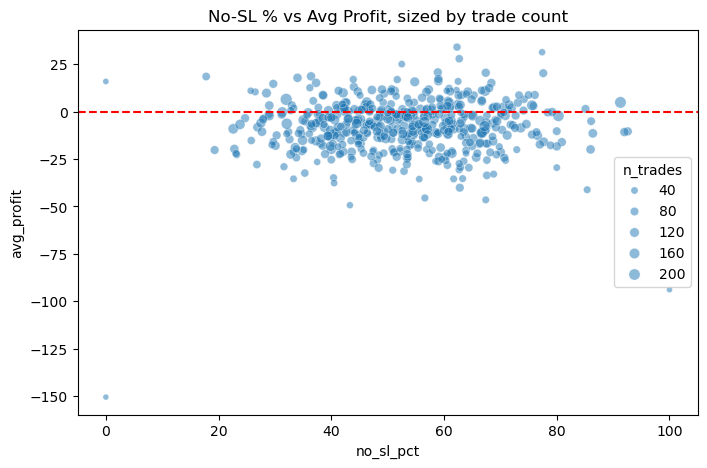

In [29]:
# 5.2 segment accounts by behavior
plt.figure(figsize=(8,5))
sns.scatterplot(data=account_summary, x='no_sl_pct', y='avg_profit', size='n_trades', alpha=0.5)
plt.title('No-SL % vs Avg Profit, sized by trade count')
plt.axhline(0, color='red', linestyle='--')
plt.show()

Look for a visible split — is there a cluster of high-no-SL, negative-profit accounts distinct from disciplined ones? This is your segmentation, visually, before you ever run a clustering algorithm.

In [30]:
#5.3 outlier accounts
# Highest volume accounts
account_summary.sort_values('n_trades', ascending=False).head(10)

# Worst performing accounts
account_summary.sort_values('avg_profit').head(10)

# Best performing accounts
account_summary.sort_values('avg_profit', ascending=False).head(10)

,accountId,n_trades,avg_profit,total_profit,profit_volatility,avg_duration,avg_lot,no_sl_pct,no_tp_pct
89,D#1702409,61,34.047869,2076.92,131.665956,1102.163934,0.263443,62.3,50.8
40,D#1702712,31,31.344839,971.69,152.331892,2555.967742,0.150323,77.4,74.2
185,D#1614609,67,27.901343,1869.39,99.811712,1379.731343,0.259552,62.7,61.2
434,D#1702704,40,25.068750,1002.75,76.839557,1626.600000,0.277000,52.5,47.5
117,D#1702516,90,20.739778,1866.58,118.271417,1486.911111,0.100778,58.9,65.6
500,D#1702703,95,20.507263,1948.19,97.828216,1867.515789,0.238842,67.4,37.9
381,D#1702338,85,20.284353,1724.17,112.618445,1369.729412,0.175412,77.6,48.2
184,D#1589450,99,18.628990,1844.27,104.603615,1510.353535,0.149899,36.4,31.3
299,D#1702701,73,18.518767,1351.87,106.537086,1789.616438,0.186575,17.8,15.1
442,D#1702666,103,17.836796,1837.19,124.016700,1445.485437,0.137184,34.0,24.3


Phase 7 — Hypothesis Generation & Testing

Hypothesis: "Accounts with higher no-SL% have worse average profit."



In [32]:
from scipy import stats

high_no_sl = account_summary[account_summary['no_sl_pct'] >= 50]['avg_profit']
low_no_sl = account_summary[account_summary['no_sl_pct'] < 50]['avg_profit']

t_stat, p_value = stats.ttest_ind(high_no_sl, low_no_sl, equal_var=False)
print(f"High no-SL avg profit: {high_no_sl.mean():.2f}")
print(f"Low no-SL avg profit: {low_no_sl.mean():.2f}")
print(f"t-stat: {t_stat:.3f}, p-value: {p_value:.4f}")

High no-SL avg profit: -7.57
Low no-SL avg profit: -8.52
t-stat: 0.715, p-value: 0.4748


In [34]:
#SUMMARY

print("=== EDA SUMMARY ===")
print(f"Total trades: {len(df):,}")
print(f"Total accounts: {df['accountId'].nunique()}")
print(f"Campaigns covered: {df['campaignId'].nunique()}")
print(f"Overall avg profit: {df['netProfit'].mean():.2f}")
print(f"% trades with no SL: {(df['slPrice'].isnull().sum() / len(df) * 100):.1f}%")
print(f"% trades with no TP: {(df['tpPrice'].isnull().sum() / len(df) * 100):.1f}%")

=== EDA SUMMARY ===
Total trades: 46,520
Total accounts: 502
Campaigns covered: 34
Overall avg profit: -6.69
% trades with no SL: 52.9%
% trades with no TP: 45.0%
